# Binary Classification - F1 Podium Prediction

Model klasifikasi biner untuk memprediksi probabilitas podium.

## Model:
1. Logistic Regression (baseline ML)
2. Random Forest
3. XGBoost
4. LightGBM
5. CatBoost

## Split:
- Train: 2014-2022
- Validation: 2023
- Test: 2024-2025

## Evaluasi:
- ROC-AUC, PR-AUC, Log Loss
- Podium Hit Rate, Winner Accuracy, Exact Podium Drivers
- NDCG@3

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Load dataset
df = pd.read_parquet('../data/processed/model_dataset.parquet')
print(f'Dataset shape: {df.shape}')
print(f'Columns: {df.shape[1]}')
print(f'Years: {df["year"].min()} - {df["year"].max()}')

Dataset shape: (5303, 66)
Columns: 66
Years: 2014 - 2026


In [2]:
# Definisikan fitur (tanpa kolom identitas dan target)
id_columns = ['raceId', 'driverId', 'constructorId', 'year', 'round',
              'circuitId', 'date', 'race_name', 'driverRef', 'team',
              'positionOrder', 'is_podium']

feature_cols = [c for c in df.columns if c not in id_columns]
print(f'Jumlah fitur: {len(feature_cols)}')
print(f'\nFitur:')
for f in feature_cols:
    print(f'  - {f}')

Jumlah fitur: 54

Fitur:
  - qualy_position
  - grid_effective
  - qual_gap_to_pole
  - reached_q2
  - reached_q3
  - driver_finish_avg_3
  - driver_finish_avg_5
  - driver_finish_avg_10
  - driver_points_avg_3
  - driver_points_avg_5
  - driver_points_avg_10
  - driver_podium_rate_5
  - driver_podium_rate_10
  - driver_win_rate_10
  - driver_dnf_rate_5
  - driver_dnf_rate_10
  - driver_grid_gain_avg_5
  - driver_prev_finish
  - driver_prev_qualy
  - team_points_avg_5
  - team_points_avg_10
  - team_podium_rate_10
  - team_win_rate_10
  - team_dnf_rate_5
  - team_dnf_rate_10
  - constructor_prev_points
  - constructor_prev_position
  - prev_standing_pos
  - prev_standing_points
  - prev_points_gap_to_leader
  - prev_constructor_pos
  - prev_constructor_points
  - prev_cons_gap_to_leader
  - driver_circuit_races
  - driver_circuit_avg_finish
  - driver_circuit_podium_rate
  - driver_circuit_best_finish
  - team_circuit_races
  - team_circuit_avg_finish
  - team_circuit_podium_rate
  - t

In [3]:
# Time-based split
train_mask = df['year'] <= 2022
val_mask = df['year'] == 2023
test_mask = df['year'] >= 2024

X_train = df[train_mask][feature_cols].copy()
y_train = df[train_mask]['is_podium'].copy()

X_val = df[val_mask][feature_cols].copy()
y_val = df[val_mask]['is_podium'].copy()

X_test = df[test_mask][feature_cols].copy()
y_test = df[test_mask]['is_podium'].copy()

# Simpan metadata untuk evaluasi per race
test_meta = df[test_mask][['raceId', 'year', 'round', 'driverId', 'constructorId',
                           'driverRef', 'team', 'positionOrder', 'is_podium',
                           'race_name']].copy()

print(f'Train   : {X_train.shape} (podium: {y_train.sum()}/{len(y_train)} = {y_train.mean():.3f})')
print(f'Val     : {X_val.shape} (podium: {y_val.sum()}/{len(y_val)} = {y_val.mean():.3f})')
print(f'Test    : {X_test.shape} (podium: {y_test.sum()}/{len(y_test)} = {y_test.mean():.3f})')

Train   : (3707, 54) (podium: 546/3707 = 0.147)
Val     : (440, 54) (podium: 66/440 = 0.150)
Test    : (1156, 54) (podium: 171/1156 = 0.148)


## Handling Missing Values

Isi missing values dengan median untuk numeric features.

In [4]:
# Cek missing values
missing = X_train.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(f'Fitur dengan missing values di train: {len(missing)}')
display(missing.head(20))

Fitur dengan missing values di train: 34


qual_gap_to_pole                58
driver_prev_qualy               48
driver_crash_rate_5             33
driver_mechanical_dnf_rate_5    33
qual_win_rate_vs_teammate_5     33
race_win_rate_vs_teammate_5     33
prev_points_gap_to_leader       32
driver_finish_avg_5             32
driver_points_avg_3             32
driver_finish_avg_3             32
driver_dnf_rate_5               32
driver_dnf_rate_10              32
driver_win_rate_10              32
driver_podium_rate_10           32
driver_points_avg_5             32
driver_points_avg_10            32
driver_podium_rate_5            32
driver_finish_avg_10            32
driver_prev_finish              32
driver_grid_gain_avg_5          32
dtype: int64

In [5]:
# Impute dengan median dari train
median_values = X_train.median()

X_train = X_train.fillna(median_values)
X_val = X_val.fillna(median_values)
X_test = X_test.fillna(median_values)

print(f'Missing setelah impute:')
print(f'  Train: {X_train.isna().sum().sum()}')
print(f'  Val: {X_val.isna().sum().sum()}')
print(f'  Test: {X_test.isna().sum().sum()}')

Missing setelah impute:
  Train: 0
  Val: 0
  Test: 0


In [6]:
# Scale fitur untuk Logistic Regression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

## Evaluation Utilities

Fungsi untuk evaluasi model baik di level baris maupun level race.

In [7]:
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             log_loss, brier_score_loss, precision_score,
                             recall_score, f1_score)

def evaluate_proba(y_true, y_prob, label='Model'):
    """Evaluasi probabilitas"""
    results = {
        'Model': label,
        'ROC-AUC': roc_auc_score(y_true, y_prob),
        'PR-AUC': average_precision_score(y_true, y_prob),
        'Log Loss': log_loss(y_true, y_prob),
        'Brier Score': brier_score_loss(y_true, y_prob)
    }
    return results


def podium_predictions_per_race(df_meta, y_prob, label='Model'):
    """
    Evaluasi prediksi podium per race.
    3 pembalap dengan probabilitas tertinggi per race = prediksi podium.
    """
    df_meta = df_meta.copy()
    df_meta['podium_prob'] = y_prob
    
    race_results = []
    
    for race_id, group in df_meta.groupby('raceId'):
        if len(group) < 3:
            continue
        
        # Aktual
        actual_podium = group[group['positionOrder'] <= 3]['driverRef'].tolist()
        actual_p1 = group[group['positionOrder'] == 1]['driverRef'].values
        
        if len(actual_podium) < 3 or len(actual_p1) == 0:
            continue
        
        # Prediksi: 3 prob tertinggi
        top3 = group.nlargest(3, 'podium_prob')
        predicted_podium = top3['driverRef'].tolist()
        predicted_p1 = top3.iloc[0]['driverRef']
        
        # Relevance untuk NDCG
        group['relevance'] = group['positionOrder'].apply(
            lambda x: 3 if x == 1 else (2 if x == 2 else (1 if x == 3 else 0))
        )
        
        # Urutkan berdasarkan probabilitas prediksi
        predicted = group.sort_values('podium_prob', ascending=False)
        predicted_rel = predicted.head(3)['relevance'].tolist()
        
        # NDCG@3
        dcg = sum((2**rel - 1) / np.log2(i + 2) for i, rel in enumerate(predicted_rel))
        ideal_rel = sorted(group['relevance'].tolist(), reverse=True)[:3]
        idcg = sum((2**rel - 1) / np.log2(i + 2) for i, rel in enumerate(ideal_rel))
        ndcg = dcg / idcg if idcg > 0 else 0
        
        hits = sum(1 for d in actual_podium if d in predicted_podium)
        exact_drivers = all(d in predicted_podium for d in actual_podium)
        winner_correct = actual_p1[0] == predicted_p1
        
        race_results.append({
            'raceId': race_id,
            'year': group['year'].iloc[0],
            'race_name': group['race_name'].iloc[0],
            'podium_hits': hits,
            'exact_drivers': int(exact_drivers),
            'winner_correct': int(winner_correct),
            'ndcg': ndcg,
            'n_drivers': len(group)
        })
    
    results_df = pd.DataFrame(race_results)
    
    total_races = len(results_df)
    total_hits = results_df['podium_hits'].sum()
    possible_hits = total_races * 3
    
    print(f'=== {label} ===')
    print(f'Total races: {total_races}')
    print(f'Podium Hit Rate: {total_hits}/{possible_hits} = {total_hits/possible_hits:.4f}')
    print(f'Rata-rata podium hits/race: {results_df["podium_hits"].mean():.4f}')
    print(f'Exact Podium Drivers: {results_df["exact_drivers"].mean():.4f}')
    print(f'Winner Accuracy: {results_df["winner_correct"].mean():.4f}')
    print(f'NDCG@3: {results_df["ndcg"].mean():.4f}')
    print()
    
    return results_df

## Logistic Regression

Baseline ML sederhana dengan class_weight balanced.

In [8]:
from sklearn.linear_model import LogisticRegression

# Logistic Regression dengan class weight
lr = LogisticRegression(
    class_weight='balanced',
    C=1.0,
    max_iter=1000,
    random_state=42
)
lr.fit(X_train_scaled, y_train)

# Probabilitas
lr_prob_val = lr.predict_proba(X_val_scaled)[:, 1]
lr_prob_test = lr.predict_proba(X_test_scaled)[:, 1]

# Evaluasi proba
lr_val_metrics = evaluate_proba(y_val, lr_prob_val, 'Logistic Regression (Val)')
lr_test_metrics = evaluate_proba(y_test, lr_prob_test, 'Logistic Regression (Test)')

print('Validation:')
for k, v in lr_val_metrics.items():
    if k != 'Model':
        print(f'  {k}: {v:.4f}')
print()
print('Test:')
for k, v in lr_test_metrics.items():
    if k != 'Model':
        print(f'  {k}: {v:.4f}')

Validation:
  ROC-AUC: 0.9391
  PR-AUC: 0.7552
  Log Loss: 0.2873
  Brier Score: 0.0868

Test:
  ROC-AUC: 0.9450
  PR-AUC: 0.7189
  Log Loss: 0.3042
  Brier Score: 0.0866


In [9]:
# Evaluasi podium-level
lr_test_podium = podium_predictions_per_race(test_meta, lr_prob_test, 'Logistic Regression')

=== Logistic Regression ===
Total races: 57
Podium Hit Rate: 122/171 = 0.7135
Rata-rata podium hits/race: 2.1404
Exact Podium Drivers: 0.2281
Winner Accuracy: 0.5263
NDCG@3: 0.7628



## Random Forest

Model ensemble dengan class_weight balanced.

In [10]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    max_depth=10,
    min_samples_leaf=10,
    n_jobs=-1,
    random_state=42
)
rf.fit(X_train, y_train)

rf_prob_val = rf.predict_proba(X_val)[:, 1]
rf_prob_test = rf.predict_proba(X_test)[:, 1]

rf_val_metrics = evaluate_proba(y_val, rf_prob_val, 'Random Forest (Val)')
rf_test_metrics = evaluate_proba(y_test, rf_prob_test, 'Random Forest (Test)')

print('Validation:')
for k, v in rf_val_metrics.items():
    if k != 'Model':
        print(f'  {k}: {v:.4f}')
print()
print('Test:')
for k, v in rf_test_metrics.items():
    if k != 'Model':
        print(f'  {k}: {v:.4f}')

Validation:
  ROC-AUC: 0.9487
  PR-AUC: 0.8200
  Log Loss: 0.2752
  Brier Score: 0.0864

Test:
  ROC-AUC: 0.9601
  PR-AUC: 0.7769
  Log Loss: 0.2761
  Brier Score: 0.0859


In [11]:
rf_test_podium = podium_predictions_per_race(test_meta, rf_prob_test, 'Random Forest')

=== Random Forest ===
Total races: 57
Podium Hit Rate: 128/171 = 0.7485
Rata-rata podium hits/race: 2.2456
Exact Podium Drivers: 0.3333
Winner Accuracy: 0.5614
NDCG@3: 0.7930



## XGBoost

Gradient boosting dengan scale_pos_weight untuk imbalance.

In [12]:
from xgboost import XGBClassifier

# Hitung scale_pos_weight
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight = neg_count / pos_count
print(f'scale_pos_weight: {scale_pos_weight:.2f}')

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)
xgb.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

xgb_prob_val = xgb.predict_proba(X_val)[:, 1]
xgb_prob_test = xgb.predict_proba(X_test)[:, 1]

xgb_val_metrics = evaluate_proba(y_val, xgb_prob_val, 'XGBoost (Val)')
xgb_test_metrics = evaluate_proba(y_test, xgb_prob_test, 'XGBoost (Test)')

print('Validation:')
for k, v in xgb_val_metrics.items():
    if k != 'Model':
        print(f'  {k}: {v:.4f}')
print()
print('Test:')
for k, v in xgb_test_metrics.items():
    if k != 'Model':
        print(f'  {k}: {v:.4f}')

scale_pos_weight: 5.79
Validation:
  ROC-AUC: 0.9631
  PR-AUC: 0.8274
  Log Loss: 0.2002
  Brier Score: 0.0549

Test:
  ROC-AUC: 0.9630
  PR-AUC: 0.8013
  Log Loss: 0.2356
  Brier Score: 0.0619


In [13]:
xgb_test_podium = podium_predictions_per_race(test_meta, xgb_prob_test, 'XGBoost')

=== XGBoost ===
Total races: 57
Podium Hit Rate: 129/171 = 0.7544
Rata-rata podium hits/race: 2.2632
Exact Podium Drivers: 0.3333
Winner Accuracy: 0.4386
NDCG@3: 0.7737



## LightGBM

Model kandidat utama dengan class_weight dan early stopping.

In [14]:
from lightgbm import LGBMClassifier

lgb = LGBMClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    class_weight='balanced',
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.1,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)
lgb.fit(X_train, y_train, eval_set=[(X_val, y_val)])

lgb_prob_val = lgb.predict_proba(X_val)[:, 1]
lgb_prob_test = lgb.predict_proba(X_test)[:, 1]

lgb_val_metrics = evaluate_proba(y_val, lgb_prob_val, 'LightGBM (Val)')
lgb_test_metrics = evaluate_proba(y_test, lgb_prob_test, 'LightGBM (Test)')

print('Validation:')
for k, v in lgb_val_metrics.items():
    if k != 'Model':
        print(f'  {k}: {v:.4f}')
print()
print('Test:')
for k, v in lgb_test_metrics.items():
    if k != 'Model':
        print(f'  {k}: {v:.4f}')

Validation:
  ROC-AUC: 0.9622
  PR-AUC: 0.8139
  Log Loss: 0.2179
  Brier Score: 0.0576

Test:
  ROC-AUC: 0.9684
  PR-AUC: 0.8133
  Log Loss: 0.2336
  Brier Score: 0.0581


In [15]:
lgb_test_podium = podium_predictions_per_race(test_meta, lgb_prob_test, 'LightGBM')

=== LightGBM ===
Total races: 57
Podium Hit Rate: 133/171 = 0.7778
Rata-rata podium hits/race: 2.3333
Exact Podium Drivers: 0.4035
Winner Accuracy: 0.3860
NDCG@3: 0.7820



## CatBoost

Model dengan native categorical feature handling dan class weights.

In [16]:
from catboost import CatBoostClassifier

catb = CatBoostClassifier(
    iterations=200,
    depth=6,
    learning_rate=0.1,
    auto_class_weights='Balanced',
    subsample=0.8,
    random_seed=42,
    verbose=False
)
catb.fit(X_train, y_train, eval_set=(X_val, y_val), verbose=False)

catb_prob_val = catb.predict_proba(X_val)[:, 1]
catb_prob_test = catb.predict_proba(X_test)[:, 1]

catb_val_metrics = evaluate_proba(y_val, catb_prob_val, 'CatBoost (Val)')
catb_test_metrics = evaluate_proba(y_test, catb_prob_test, 'CatBoost (Test)')

print('Validation:')
for k, v in catb_val_metrics.items():
    if k != 'Model':
        print(f'  {k}: {v:.4f}')
print()
print('Test:')
for k, v in catb_test_metrics.items():
    if k != 'Model':
        print(f'  {k}: {v:.4f}')

Validation:
  ROC-AUC: 0.9592
  PR-AUC: 0.8318
  Log Loss: 0.2415
  Brier Score: 0.0766

Test:
  ROC-AUC: 0.9667
  PR-AUC: 0.8265
  Log Loss: 0.2540
  Brier Score: 0.0789


In [17]:
catb_test_podium = podium_predictions_per_race(test_meta, catb_prob_test, 'CatBoost')

=== CatBoost ===
Total races: 57
Podium Hit Rate: 129/171 = 0.7544
Rata-rata podium hits/race: 2.2632
Exact Podium Drivers: 0.3333
Winner Accuracy: 0.5088
NDCG@3: 0.7787



## Perbandingan Semua Model

### Probabilistic Metrics

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='darkgrid')

# Tabel perbandingan proba
proba_comparison = pd.DataFrame([
    lr_test_metrics,
    rf_test_metrics,
    xgb_test_metrics,
    lgb_test_metrics,
    catb_test_metrics
])

display(proba_comparison)

,Model,ROC-AUC,PR-AUC,Log Loss,Brier Score
0,Logistic Regression (Test),0.945011,0.718944,0.304181,0.086620
1,Random Forest (Test),0.960121,0.776857,0.276125,0.085896
2,XGBoost (Test),0.963036,0.801333,0.235604,0.061878
3,LightGBM (Test),0.968368,0.813305,0.233552,0.058131
4,CatBoost (Test),0.966705,0.826498,0.253971,0.078877


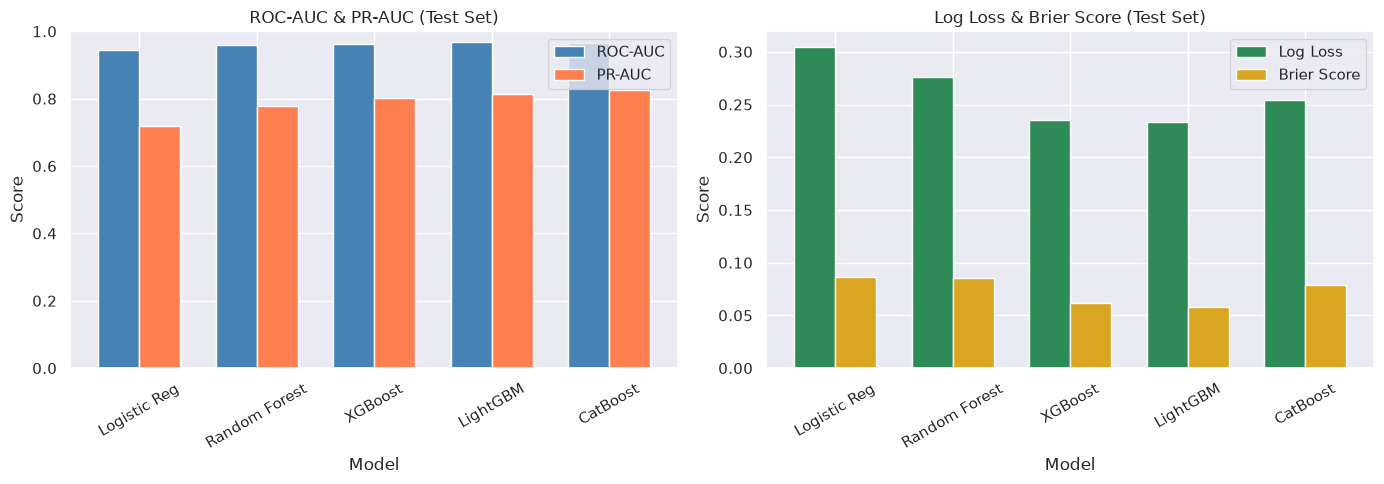

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models_label = ['Logistic Reg', 'Random Forest', 'XGBoost', 'LightGBM', 'CatBoost']

# ROC-AUC & PR-AUC
ax = axes[0]
x = np.arange(len(models_label))
width = 0.35
ax.bar(x - width/2, proba_comparison['ROC-AUC'], width, label='ROC-AUC', color='steelblue')
ax.bar(x + width/2, proba_comparison['PR-AUC'], width, label='PR-AUC', color='coral')
ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_title('ROC-AUC & PR-AUC (Test Set)')
ax.set_xticks(x)
ax.set_xticklabels(models_label, rotation=30)
ax.legend()
ax.set_ylim(0, 1)

# Log Loss & Brier
ax = axes[1]
ax.bar(x - width/2, proba_comparison['Log Loss'], width, label='Log Loss', color='seagreen')
ax.bar(x + width/2, proba_comparison['Brier Score'], width, label='Brier Score', color='goldenrod')
ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_title('Log Loss & Brier Score (Test Set)')
ax.set_xticks(x)
ax.set_xticklabels(models_label, rotation=30)
ax.legend()

plt.tight_layout()
plt.show()

In [20]:
# Tabel perbandingan podium
podium_summaries = []

for name, df_race in [
    ('Logistic Regression', lr_test_podium),
    ('Random Forest', rf_test_podium),
    ('XGBoost', xgb_test_podium),
    ('LightGBM', lgb_test_podium),
    ('CatBoost', catb_test_podium)
]:
    total = len(df_race)
    hits = df_race['podium_hits'].sum()
    podium_summaries.append({
        'Model': name,
        'Total Races': total,
        'Podium Hit Rate': hits / (total * 3),
        'Avg Podium Hits': df_race['podium_hits'].mean(),
        'Winner Accuracy': df_race['winner_correct'].mean(),
        'Exact Drivers': df_race['exact_drivers'].mean(),
        'NDCG@3': df_race['ndcg'].mean()
    })

podium_comparison = pd.DataFrame(podium_summaries)
display(podium_comparison)

,Model,Total Races,Podium Hit Rate,Avg Podium Hits,Winner Accuracy,Exact Drivers,NDCG@3
0,Logistic Regression,57,0.713450,2.140351,0.526316,0.228070,0.762789
1,Random Forest,57,0.748538,2.245614,0.561404,0.333333,0.793030
2,XGBoost,57,0.754386,2.263158,0.438596,0.333333,0.773750
3,LightGBM,57,0.777778,2.333333,0.385965,0.403509,0.782043
4,CatBoost,57,0.754386,2.263158,0.508772,0.333333,0.778666


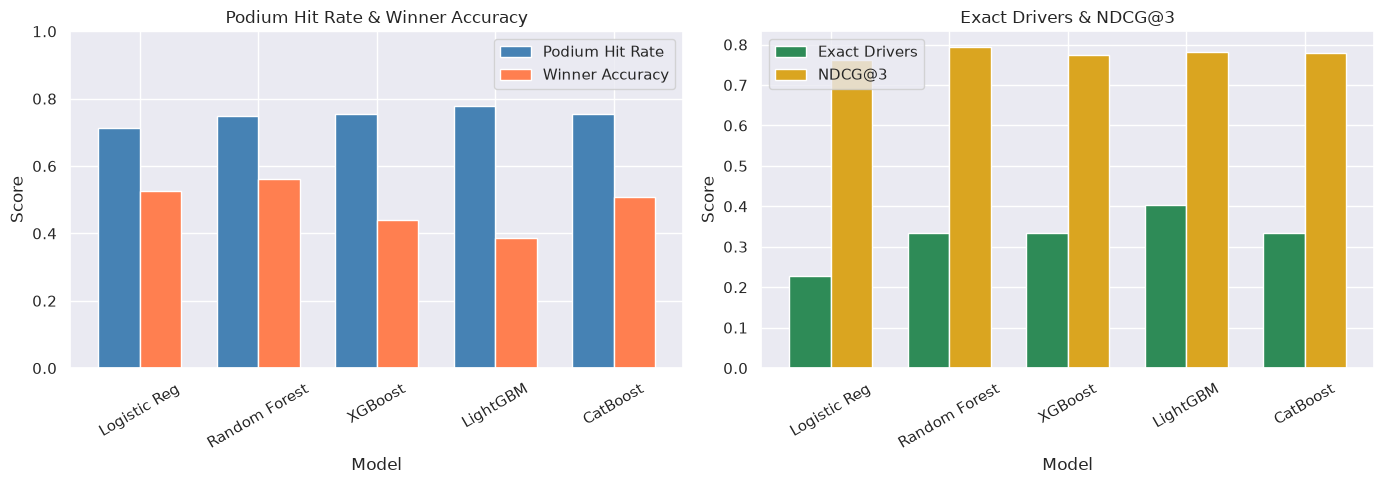

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Podium Hit Rate & Winner Accuracy
ax = axes[0]
ax.bar(x - width/2, podium_comparison['Podium Hit Rate'], width, label='Podium Hit Rate', color='steelblue')
ax.bar(x + width/2, podium_comparison['Winner Accuracy'], width, label='Winner Accuracy', color='coral')
ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_title('Podium Hit Rate & Winner Accuracy')
ax.set_xticks(x)
ax.set_xticklabels(models_label, rotation=30)
ax.legend()
ax.set_ylim(0, 1)

# Exact Drivers & NDCG@3
ax = axes[1]
ax.bar(x - width/2, podium_comparison['Exact Drivers'], width, label='Exact Drivers', color='seagreen')
ax.bar(x + width/2, podium_comparison['NDCG@3'], width, label='NDCG@3', color='goldenrod')
ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_title('Exact Drivers & NDCG@3')
ax.set_xticks(x)
ax.set_xticklabels(models_label, rotation=30)
ax.legend()

plt.tight_layout()
plt.show()

## Feature Importance

Lihat fitur paling penting dari LightGBM (model terbaik).

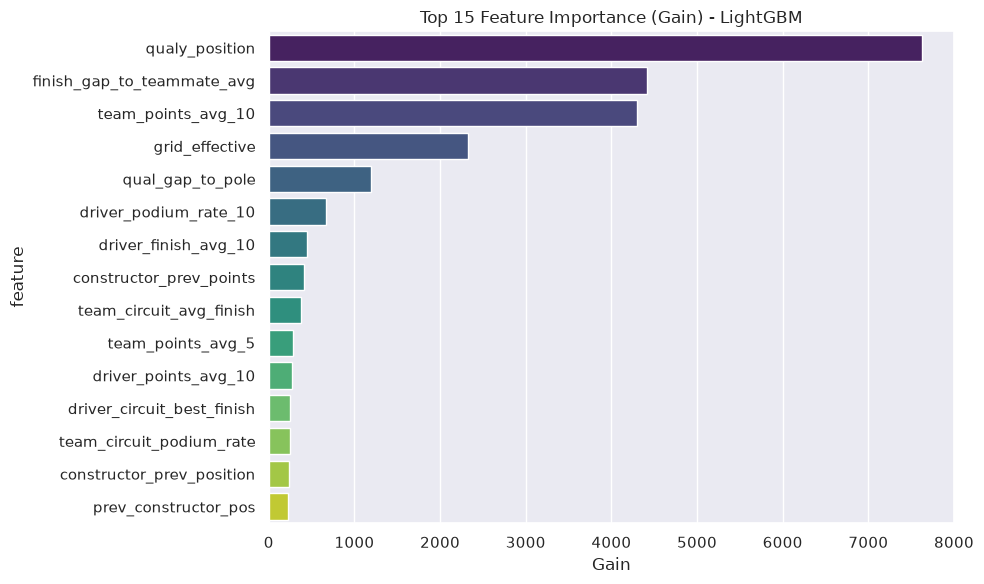

,feature,gain,split
0,qualy_position,7620.624522,104
51,finish_gap_to_teammate_avg,4416.802750,472
20,team_points_avg_10,4304.730303,179
1,grid_effective,2322.661297,118
2,qual_gap_to_pole,1196.533502,250
12,driver_podium_rate_10,671.784505,25
7,driver_finish_avg_10,441.708491,146
25,constructor_prev_points,416.437962,131
38,team_circuit_avg_finish,373.466926,169
19,team_points_avg_5,283.733150,159


In [22]:
# Feature importance dari LightGBM
lgb_importance = pd.DataFrame({
    'feature': feature_cols,
    'gain': lgb.booster_.feature_importance(importance_type='gain'),
    'split': lgb.booster_.feature_importance(importance_type='split')
}).sort_values('gain', ascending=False)

# Top 15
top15 = lgb_importance.head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=top15, y='feature', x='gain', palette='viridis')
plt.title('Top 15 Feature Importance (Gain) - LightGBM')
plt.xlabel('Gain')
plt.tight_layout()
plt.show()

display(top15)

In [23]:
# Simpan hasil perbandingan
proba_comparison.to_csv('../reports/metrics/classifier_proba_results.csv', index=False)
podium_comparison.to_csv('../reports/metrics/classifier_podium_results.csv', index=False)

print('Results saved.')
print(f'\nBest model by PR-AUC: {proba_comparison.loc[proba_comparison["PR-AUC"].idxmax(), "Model"]}')
print(f'Best model by Podium Hit Rate: {podium_comparison.loc[podium_comparison["Podium Hit Rate"].idxmax(), "Model"]}')

Results saved.

Best model by PR-AUC: CatBoost (Test)
Best model by Podium Hit Rate: LightGBM


In [24]:
import joblib
import os

# Buat direktori jika belum ada
os.makedirs('../models/classifier/', exist_ok=True)

# Simpan LightGBM (model classifier terbaik)
joblib.dump(lgb, '../models/classifier/lgb_classifier.pkl')
print(f'LightGBM model saved: models/classifier/lgb_classifier.pkl')

# Simpan XGBoost sebagai alternatif
joblib.dump(xgb, '../models/classifier/xgb_classifier.pkl')
print(f'XGBoost model saved: models/classifier/xgb_classifier.pkl')

# Simpan Logistic Regression untuk baseline ML
joblib.dump(lr, '../models/classifier/lr_classifier.pkl')
print(f'Logistic Regression saved: models/classifier/lr_classifier.pkl')

# Simpan scaler untuk preprocessing
joblib.dump(scaler, '../models/classifier/scaler.pkl')
print(f'Scaler saved: models/classifier/scaler.pkl')

# Simpan median values untuk impute
joblib.dump(median_values, '../models/classifier/median_values.pkl')
print(f'Median values saved: models/classifier/median_values.pkl')

# Simpan daftar feature columns
joblib.dump(feature_cols, '../models/classifier/feature_cols.pkl')
print(f'Feature columns saved: models/classifier/feature_cols.pkl')

# Simpan id_columns untuk evaluasi
joblib.dump(id_columns, '../models/classifier/id_columns.pkl')
print(f'ID columns saved: models/classifier/id_columns.pkl')

print('\nSemua model berhasil disimpan.')

LightGBM model saved: models/classifier/lgb_classifier.pkl
XGBoost model saved: models/classifier/xgb_classifier.pkl
Logistic Regression saved: models/classifier/lr_classifier.pkl
Scaler saved: models/classifier/scaler.pkl
Median values saved: models/classifier/median_values.pkl
Feature columns saved: models/classifier/feature_cols.pkl
ID columns saved: models/classifier/id_columns.pkl

Semua model berhasil disimpan.
